In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()

Один объект (одна строка) = один район (census block group) в Калифорнии.
Наш target - MedHouseVal - Это медианная стоимость домов в данном районе. Причём значение в датасете измеряется в сотнях тысяч долларов.
Внутри каждого района собиралась статистика по households (домохозяйствам). Домохозяйство — это люди, которые живут вместе и ведут совместное хозяйство. Это не обязательно буквально один человек и не обязательно одна семья. Поэтому некоторые признаки — это средние или медианные характеристики домохозяйств внутри района.
    Median Income — медианный доход домохозяйства в районе. Это не средняя зарплата человека. 
Например, если: MedInc = 3.5 это означает примерно $35 000 медианного дохода домохозяйства в год.
Почему 3.5, а не 35000?
Потому что доход здесь масштабирован: значение умножается на $10 000.
    Average Rooms — среднее количество комнат на домохозяйство в районе.
    Average Bedrooms — среднее количество спален на домохозяйство.
    Population - Население района.
    Average Occupancy — среднее количество людей на домохозяйство в районе.
    

In [ ]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)

In [ ]:
y = pd.DataFrame(data.target, columns=data.target_names)

In [ ]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
full_data = pd.concat([X, y], axis=1)

In [ ]:
full_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
full_data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
full_data.corr()  # корреляционная матрица, для выявления линейных зависимостей

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


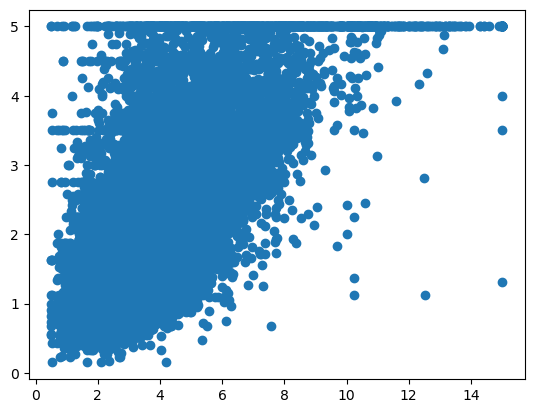

In [ ]:
plt.scatter(X["MedInc"], y)
plt.show()

<Axes: >

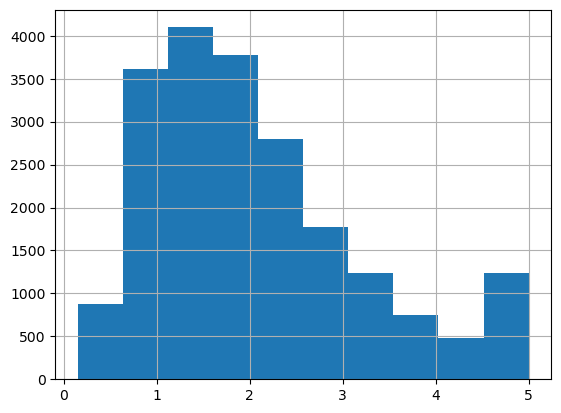

In [ ]:
full_data["MedHouseVal"].hist()

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

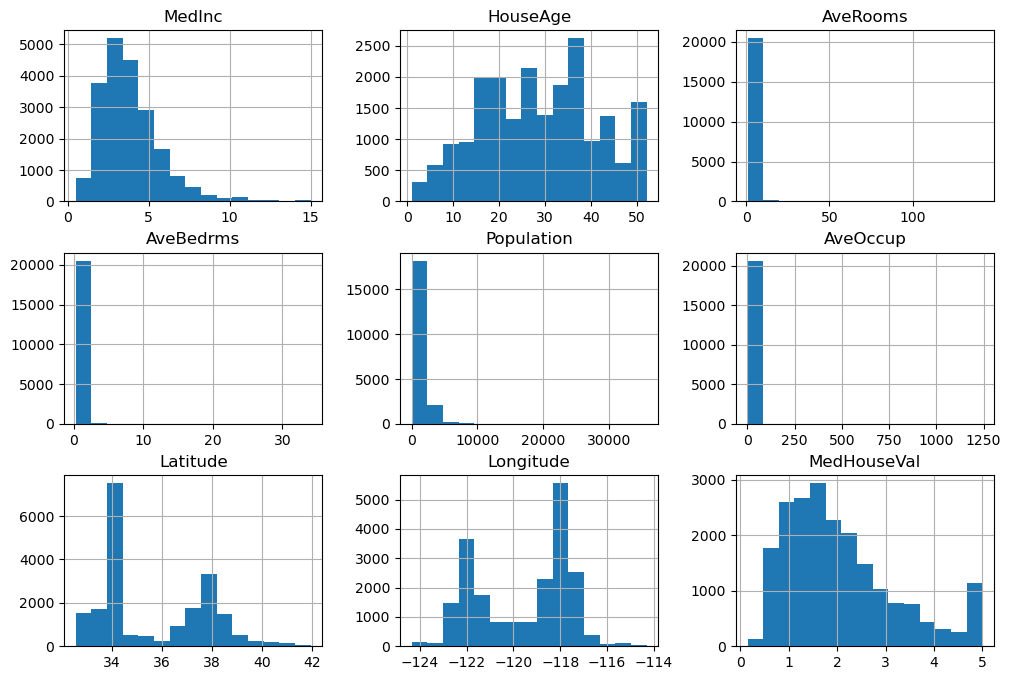

In [ ]:
full_data.hist(figsize=(12, 8), bins=15)

<Axes: >

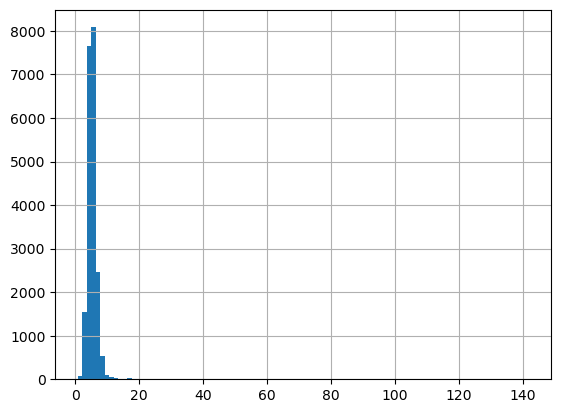

In [ ]:
full_data["AveRooms"].hist(bins=100)

<Axes: >

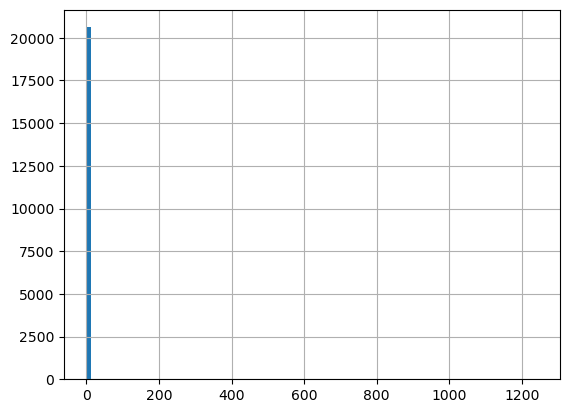

In [ ]:
full_data["AveOccup"].hist(bins=100)

<Axes: >

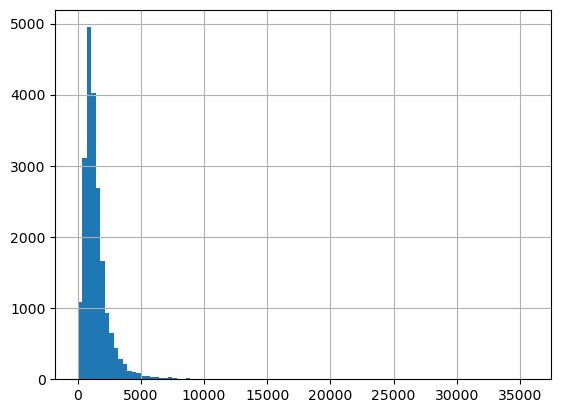

In [ ]:
full_data["Population"].hist(bins=100)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_train_mean = y_train.mean()
y_pred_baseline = pd.DataFrame(
    np.full(y_test.shape, y_train_mean)
)  # создаём baseline (простую модель, с которой будем сравнивать последующие)
y_pred_baseline

,0
0,2.071947
1,2.071947
2,2.071947
3,2.071947
4,2.071947
...,...
4123,2.071947
4124,2.071947
4125,2.071947
4126,2.071947


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
print(mae_baseline)
print(rmse_baseline)

0.9060685490007149
1.1448563543099792


In [ ]:
from sklearn.linear_model import LinearRegression

model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train)
y_pred_model_lin_reg = model_lin_reg.predict(X_test)

mae_lin_reg = mean_absolute_error(y_test, y_pred_model_lin_reg)
rmse_lin_reg = root_mean_squared_error(y_test, y_pred_model_lin_reg)

print(mae_lin_reg)
print(rmse_lin_reg)

0.5332001304956553
0.7455813830127764


In [ ]:
from sklearn.metrics import r2_score

r2_score_baseline = r2_score(y_test, y_pred_baseline)
r2_score_lin_reg = r2_score(y_test, y_pred_model_lin_reg)

print(r2_score_baseline)
print(r2_score_lin_reg)

-0.00021908714592466794
0.5757877060324508


In [ ]:
print(model_lin_reg.coef_)
print(model_lin_reg.intercept_)

[[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
  -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]]
[-37.02327771]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_lin_reg_pipeline = Pipeline([("scaler", StandardScaler()), ("regressor", LinearRegression())])
model_lin_reg_pipeline.fit(X_train, y_train)
y_pred_pipeline_lin_reg = model_lin_reg_pipeline.predict(X_test)

mae_pipeline_lin_reg = mean_absolute_error(y_test, y_pred_pipeline_lin_reg)
rmse_pipeline_lin_reg = root_mean_squared_error(y_test, y_pred_pipeline_lin_reg)

print(mae_pipeline_lin_reg)
print(rmse_pipeline_lin_reg)
print(model_lin_reg_pipeline.named_steps["regressor"].coef_)
print(model_lin_reg_pipeline.named_steps["regressor"].intercept_)

0.5332001304956565
0.7455813830127763
[[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
  -0.89692888 -0.86984178]]
[2.07194694]


In [ ]:
residual_lin_alg = y_test - y_pred_model_lin_reg
print(residual_lin_alg)

       MedHouseVal
20046    -0.242123
3024     -1.306017
15663     2.290351
20484    -0.652926
9814      0.175343
...            ...
15362     0.641254
16623     0.418161
18086     0.531240
2144     -0.464511
3665     -0.494403

[4128 rows x 1 columns]


In [ ]:
print(residual_lin_alg.mean())
print(residual_lin_alg.min())
print(residual_lin_alg.max())

MedHouseVal    0.003479
dtype: float64
MedHouseVal   -9.875331
dtype: float64
MedHouseVal    4.148388
dtype: float64


array([[<Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

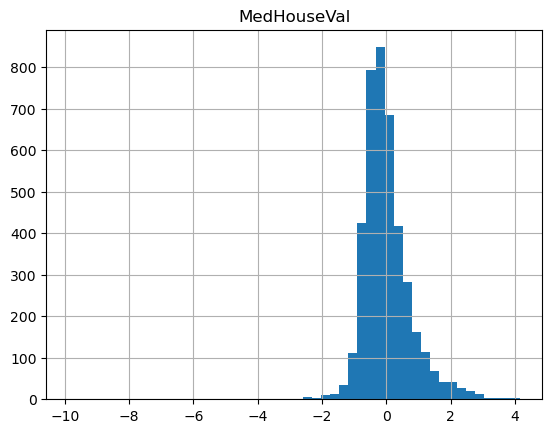

In [ ]:
residual_lin_alg.hist(bins=50)

In [ ]:
min_n = residual_lin_alg.idxmin()
print(min_n)
print(y_test.loc[min_n])

MedHouseVal    1979
dtype: int64
      MedHouseVal
1979        1.625


In [ ]:
pos_y_pred = y_test.index.get_loc(1979)
pos_y_pred

3722

In [ ]:
y_pred_model_lin_reg[pos_y_pred]

array([11.50033103])

In [ ]:
X_test.loc[min_n]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1979,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08


In [ ]:
X_test[X_test["AveBedrms"] > 20]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1979,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08


In [ ]:
X_train[X_train["AveBedrms"] > 20]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1914,1.875,33.0,141.909091,25.636364,30.0,2.727273,38.91,-120.1


In [ ]:
X_train_clean = X_train[X_train["AveBedrms"] <= 20]
y_train_clean = y_train[X_train["AveBedrms"] <= 20]

In [ ]:
X_train_clean.shape

(16511, 8)

In [ ]:
y_train_clean.shape

(16511, 1)

In [ ]:
model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = model_clean.predict(X_test)

mae_clean = mean_absolute_error(y_test, y_pred_clean)
rmse_clean = root_mean_squared_error(y_test, y_pred_clean)

print(mae_clean)
print(rmse_clean)

0.5334039534791829
0.7436762884281753


In [ ]:
print(mae_pipeline_lin_reg)
print(rmse_pipeline_lin_reg)

0.5332001304956565
0.7455813830127763


Мы убрали объект из обучения, но сам объект с огромным residual находится в test.
Поэтому модель всё равно должна была предсказать его — и продолжает делать это плохо.
экстремальное наблюдение в train немного влияет на обучение, но главная проблема — сама линейная модель плохо справляется с таким типом данных.
И это уже подводит нас к следующему вопросу: а может, Linear Regression вообще недостаточно хорошо описывает зависимость в California Housing?

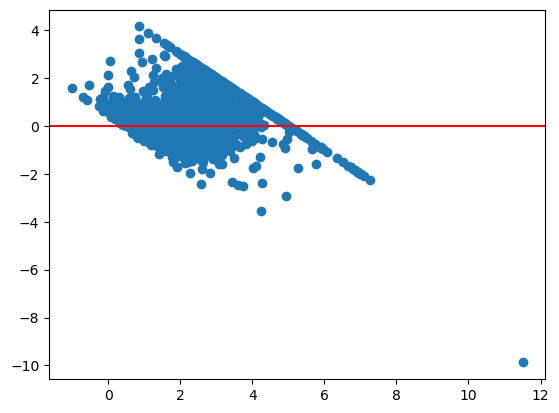

In [ ]:
plt.scatter(y_pred_model_lin_reg, residual_lin_alg)
plt.axhline(y=0, color="red")
plt.show()

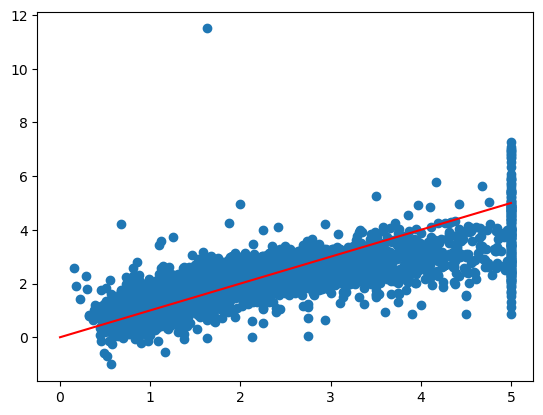

In [ ]:
plt.scatter(y_test, y_pred_model_lin_reg)
plt.plot((0, 5), (0, 5), color="red")
plt.show()

In [ ]:
mean_residual_0_2 = residual_lin_alg[y_pred_model_lin_reg < 2].mean()
mean_residual_0_2

MedHouseVal   -0.034523
dtype: float64

In [ ]:
mean_residual_2_10 = residual_lin_alg[y_pred_model_lin_reg >= 2].mean()
mean_residual_2_10

MedHouseVal    0.041042
dtype: float64

In [ ]:
abs_res = abs(residual_lin_alg)

In [ ]:
mean_abs_res_0_2 = abs_res[y_pred_model_lin_reg < 2].mean()
mean_abs_res_2_10 = abs_res[y_pred_model_lin_reg >= 2].mean()
print(mean_abs_res_0_2)
print(mean_abs_res_2_10)

MedHouseVal    0.424094
dtype: float64
MedHouseVal    0.641045
dtype: float64


In [ ]:
groups = pd.cut(y_pred_model_lin_reg.ravel(), bins=[-np.inf, 1, 2, 3, 4, np.inf])

In [ ]:
groups

[(-inf, 1.0], (1.0, 2.0], (2.0, 3.0], (2.0, 3.0], (2.0, 3.0], ..., (1.0, 2.0], (2.0, 3.0], (4.0, inf], (1.0, 2.0], (2.0, 3.0]]
Length: 4128
Categories (5, interval[float64, right]): [(-inf, 1.0] < (1.0, 2.0] < (2.0, 3.0] < (3.0, 4.0] < (4.0, inf]]

In [ ]:
mean_abs_res_groups = abs_res.groupby(groups).mean()

/tmp/ipykernel_5084/1610877050.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_abs_res_groups = abs_res.groupby(groups).mean()


In [150]:
mean_abs_res_groups

,MedHouseVal
"(-inf, 1.0]",0.386391
"(1.0, 2.0]",0.434836
"(2.0, 3.0]",0.621443
"(3.0, 4.0]",0.673085
"(4.0, inf]",0.817501


In [ ]:
comparison_bl_linreg = pd.DataFrame(
    {
        "MAE": [mae_baseline, mae_lin_reg],
        "RMSE": [rmse_baseline, rmse_lin_reg],
        "r^2": [r2_score_baseline, r2_score_lin_reg],
    },
    index=["Baseline", "LinearReg"],
)
comparison_bl_linreg

,MAE,RMSE,r^2
Baseline,0.906069,1.144856,-0.000219
LinearReg,0.533200,0.745581,0.575788
